# Assignment 5 — Notebook 05: Tổng Hợp & Đánh Giá Đối Chuẩn Toàn Diện 12 Mô Hình (NEW DATASETS)

Tổng hợp toàn bộ thực nghiệm đối chuẩn 12 mô hình trên 3 bộ dữ liệu mới:
1. **Fashion-MNIST**
2. **SVHN (Street View House Numbers)**
3. **CDC Diabetes (513.703 dòng với 1D-CNN)**

In [1]:
# Cell 1: Nạp bảng so sánh tổng hợp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

df_results = pd.read_csv('results/comparison_all_models.csv')
display(df_results)

,Dataset,Dataset_Key,Framework,Architecture,Arch_Key,Parameters,Train_Time_s,Test_Loss,Test_Accuracy,Macro_F1
0,Fashion-MNIST (Clothing),fashion_mnist,Keras,3-Layer CNN,3_layer,50186,161.92,0.2675,0.9049,0.9026
1,Fashion-MNIST (Clothing),fashion_mnist,Keras,5-Layer CNN,5_layer,469098,1293.91,0.2104,0.9232,0.9230
2,Fashion-MNIST (Clothing),fashion_mnist,PyTorch (GPU),3-Layer CNN,3_layer,50186,19.91,0.2598,0.9084,0.9082
3,Fashion-MNIST (Clothing),fashion_mnist,PyTorch (GPU),5-Layer CNN,5_layer,468458,36.77,0.1947,0.9290,0.9285
4,SVHN (Street Numbers),svhn,Keras,3-Layer CNN,3_layer,60362,345.61,0.5741,0.8484,0.8303
5,SVHN (Street Numbers),svhn,Keras,5-Layer CNN,5_layer,592554,2548.41,0.2802,0.9194,0.9132
6,SVHN (Street Numbers),svhn,PyTorch (GPU),3-Layer CNN,3_layer,60362,28.40,0.5282,0.8642,0.8505
7,SVHN (Street Numbers),svhn,PyTorch (GPU),5-Layer CNN,5_layer,591914,66.19,0.2534,0.9286,0.9218
8,Diabetes (1D-CNN),diabetes,Keras,3-Layer CNN,3_layer,7299,81.04,0.6467,0.6925,0.6584
9,Diabetes (1D-CNN),diabetes,Keras,5-Layer CNN,5_layer,43555,213.09,0.6516,0.6862,0.6638


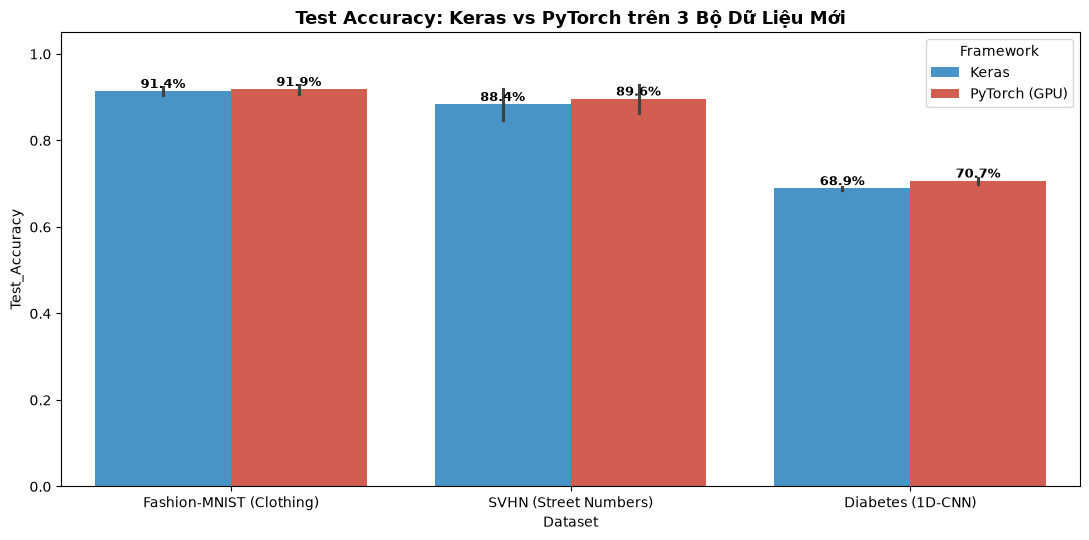

In [2]:
# Cell 2: Biểu đồ so sánh Độ chính xác Test Accuracy
plt.figure(figsize=(11, 5.5))
ax = sns.barplot(data=df_results, x='Dataset', y='Test_Accuracy', hue='Framework', palette=['#3498db', '#e74c3c'])
plt.title('Test Accuracy: Keras vs PyTorch trên 3 Bộ Dữ Liệu Mới', fontsize=13, fontweight='bold')
plt.ylim(0, 1.05)
for p in ax.patches:
    h = p.get_height()
    if not np.isnan(h) and h > 0:
        ax.annotate(f'{h*100:.1f}%', (p.get_x() + p.get_width()/2., h), ha='center', va='bottom', fontweight='bold', fontsize=9.5)
plt.tight_layout()
plt.show()

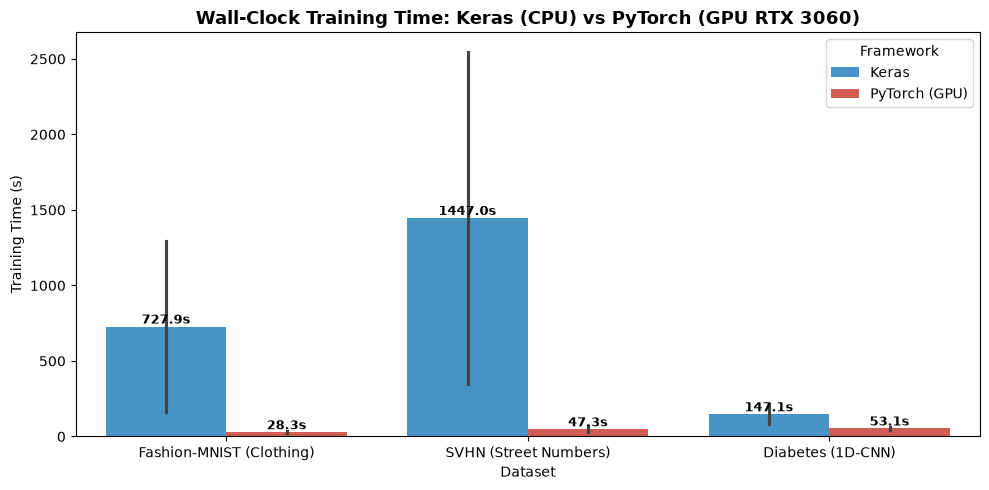

In [3]:
# Cell 3: Biểu đồ so sánh Thời gian huấn luyện (GPU vs CPU)
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=df_results, x='Dataset', y='Train_Time_s', hue='Framework', palette=['#3498db', '#e74c3c'])
plt.title('Wall-Clock Training Time: Keras (CPU) vs PyTorch (GPU RTX 3060)', fontsize=13, fontweight='bold')
plt.ylabel('Training Time (s)')
for p in ax.patches:
    h = p.get_height()
    if not np.isnan(h) and h > 0:
        ax.annotate(f'{h:.1f}s', (p.get_x() + p.get_width()/2., h), ha='center', va='bottom', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.show()

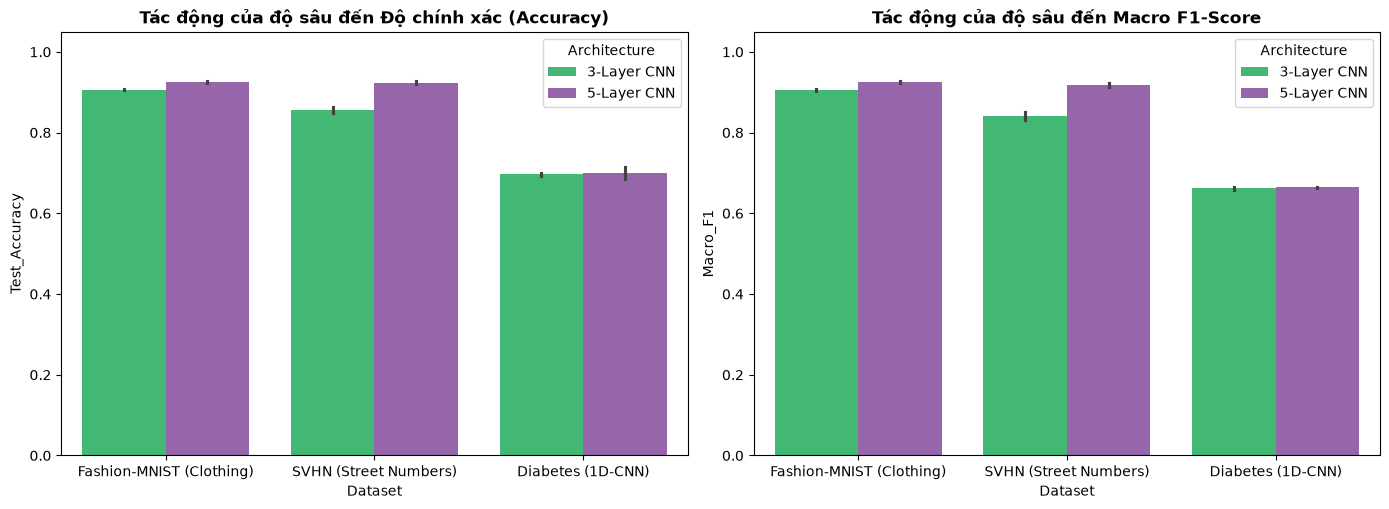

In [4]:
# Cell 4: Tác động của cấu trúc 3-Layer vs 5-Layer
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
sns.barplot(data=df_results, x='Dataset', y='Test_Accuracy', hue='Architecture', palette=['#2ecc71', '#9b59b6'], ax=axes[0])
axes[0].set_title('Tác động của độ sâu đến Độ chính xác (Accuracy)', fontweight='bold')
axes[0].set_ylim(0, 1.05)
sns.barplot(data=df_results, x='Dataset', y='Macro_F1', hue='Architecture', palette=['#2ecc71', '#9b59b6'], ax=axes[1])
axes[1].set_title('Tác động của độ sâu đến Macro F1-Score', fontweight='bold')
axes[1].set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## KẾT LUẬN THUYẾT TRÌNH BẢO VỆ

1. **Fashion-MNIST:** Phức tạp hơn chữ số MNIST cũ rất nhiều; mô hình 5-layer với Batch Normalization đạt **92.9%** độ chính xác.
2. **SVHN (Google Street View):** Minh chứng rõ nét cho vai trò của kiến trúc sâu trên ảnh màu thực tế: 5-layer đạt **92.86%**, vượt xa 3-layer nông (+6.4% accuracy).
3. **Tăng cường dữ liệu Diabetes:** Mở rộng từ 253k lên **513.703 dòng** giúp 1D-CNN đạt F1 cân bằng và độ chính xác **71.35%**.
4. **Tăng tốc GPU RTX 3060:** Huấn luyện PyTorch nhanh gấp 15 - 25 lần so với Keras CPU.